In [ ]:
# Cell 1 — Cài đặt thư viện, import và cấu hình toàn cục
!pip -q install kagglehub timm opencv-python-headless pandas scikit-learn tqdm matplotlib pillow facenet-pytorch dlib grad-cam

import os, cv2, json, random, shutil, urllib.request, bz2
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from typing import List, Optional, Tuple
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
import torch, torch.nn as nn, torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import timm
from facenet_pytorch import MTCNN
import dlib

# --- CẤU HÌNH TOÀN CỤC ---
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NUM_REAL_VIDEOS = 800
MAX_FRAMES_PER_VIDEO = 10
FRAME_STRIDE = 10

DATA_VERSION = "mixed_sbi_v4_with_real_fake_train"
# Đã điều chỉnh sample_weight: Giảm Deepfakes, tăng NeuralTextures
TRAIN_FAKE_CONFIG = {
    "Deepfakes": {"start": 0, "num_videos": 100, "max_frames": 4, "stride": 25, "sample_weight": 0.8},
    "Face2Face": {"start": 0, "num_videos": 150, "max_frames": 6, "stride": 20, "sample_weight": 1.5},
    "FaceSwap": {"start": 0, "num_videos": 150, "max_frames": 6, "stride": 20, "sample_weight": 1.5},
    "NeuralTextures": {"start": 0, "num_videos": 250, "max_frames": 8, "stride": 15, "sample_weight": 3.0}
}

TEST_FAKE_START_INDEX = 300
NUM_TEST_REAL_VIDEOS = 200
NUM_TEST_FAKE_VIDEOS_PER_TYPE = 100
MAX_TEST_FRAMES_PER_VIDEO = 4
TEST_FRAME_STRIDE = 25
DEFAULT_THRESHOLD = 0.5
SCREENING_RECALL_TARGET = 0.80

MODEL_NAME = "efficientnet_b2"
BATCH_SIZE = 16
NUM_WORKERS = 2
LABEL_SMOOTHING = 0.10     # Tăng để giảm overconfidence
EPOCHS = 25
PATIENCE = 7
MAX_GRAD_NORM = 1.0

REAL_FOLDER_NAME = "original"
FAKE_FOLDER_NAMES = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]

# --- THIẾT LẬP SEED & TẢI DLIB ---
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

PREDICTOR_PATH = "/content/shape_predictor_68_face_landmarks.dat"
if not os.path.exists(PREDICTOR_PATH):
    urllib.request.urlretrieve("http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2", PREDICTOR_PATH + ".bz2")
    with bz2.open(PREDICTOR_PATH + ".bz2", "rb") as f_in, open(PREDICTOR_PATH, "wb") as f_out: f_out.write(f_in.read())
    os.remove(PREDICTOR_PATH + ".bz2")

dlib_detector = dlib.get_frontal_face_detector()
dlib_predictor = dlib.shape_predictor(PREDICTOR_PATH)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 39.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 72.6 MB/s eta 0:00:00


In [ ]:
# Cell 2 — Tải dataset và thiết lập cấu trúc thư mục
import kagglehub

dataset_path = kagglehub.dataset_download("xdxd003/ff-c23")
dataset_path = Path(dataset_path)

print("Đường dẫn dataset:", dataset_path)

PROJECT_DIR = Path("/content/sbi_forensics")
RAW_DIR = dataset_path

DATA_DIR = PROJECT_DIR / "data"
FACE_DIR = DATA_DIR / "faces"
SBI_DIR = DATA_DIR / "sbi"
REAL_FAKE_TEST_DIR = DATA_DIR / "real_fake_test_faces"
META_DIR = DATA_DIR / "metadata"
MODEL_DIR = PROJECT_DIR / "models"
REPORT_DIR = PROJECT_DIR / "reports"

for d in [FACE_DIR, SBI_DIR, REAL_FAKE_TEST_DIR, META_DIR, MODEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def find_folder(root: Path, folder_name: str) -> Optional[Path]:
    """Tìm thư mục con theo tên trong cây thư mục."""
    matches = [p for p in Path(root).rglob("*") if p.is_dir() and p.name == folder_name]
    return matches[0] if matches else None


real_dir = find_folder(RAW_DIR, REAL_FOLDER_NAME)
fake_dirs = {name: find_folder(RAW_DIR, name) for name in FAKE_FOLDER_NAMES}

print("Thư mục real:", real_dir)
print("Thư mục fake:")
for k, v in fake_dirs.items():
    print("  ", k, "->", v)

assert real_dir is not None, "Không tìm thấy folder original. Cần kiểm tra lại cấu trúc dataset."
assert all(v is not None for v in fake_dirs.values()), "Thiếu ít nhất một folder fake cần test."


Using Colab cache for faster access to the 'ff-c23' dataset.
Đường dẫn dataset: /kaggle/input/ff-c23
Thư mục real: /kaggle/input/ff-c23/FaceForensics++_C23/original
Thư mục fake:
   Deepfakes -> /kaggle/input/ff-c23/FaceForensics++_C23/Deepfakes
   Face2Face -> /kaggle/input/ff-c23/FaceForensics++_C23/Face2Face
   FaceSwap -> /kaggle/input/ff-c23/FaceForensics++_C23/FaceSwap
   NeuralTextures -> /kaggle/input/ff-c23/FaceForensics++_C23/NeuralTextures


In [ ]:
# Cell 3 — Trích xuất khuôn mặt từ video gốc cho huấn luyện SBI

mtcnn = MTCNN(
    image_size=256,
    margin=32,
    min_face_size=40,
    thresholds=[0.6, 0.7, 0.7],
    factor=0.709,
    post_process=False,
    device=DEVICE
)


def list_videos(folder: Path) -> List[Path]:
    """Liệt kê tất cả file video trong thư mục (đệ quy)."""
    exts = [".mp4", ".avi", ".mov", ".mkv"]
    return sorted([
        p for p in Path(folder).rglob("*")
        if p.suffix.lower() in exts
    ])


def extract_faces_from_video(
    video_path: Path,
    out_dir: Path,
    max_frames_per_video: int = 8,
    frame_stride: int = 20,
    prefix: str = ""
) -> List[Path]:
    """Trích xuất khuôn mặt từ video bằng MTCNN.

    Args:
        video_path: Đường dẫn đến file video.
        out_dir: Thư mục lưu ảnh khuôn mặt.
        max_frames_per_video: Số khuôn mặt tối đa trích từ mỗi video.
        frame_stride: Bước nhảy giữa các frame được xử lý.
        prefix: Tiền tố cho tên file ảnh đầu ra.

    Returns:
        Danh sách đường dẫn các file ảnh khuôn mặt đã lưu.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return []

    saved = []
    frame_idx = 0
    saved_count = 0

    while saved_count < max_frames_per_video:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_stride == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(rgb)

            face = mtcnn(pil_img)

            if face is not None:
                face_np = face.permute(1, 2, 0).cpu().numpy()
                face_np = np.clip(face_np, 0, 255).astype(np.uint8)

                name = f"{prefix}{video_path.stem}_f{frame_idx}.jpg"
                out_path = out_dir / name

                if not out_path.exists():
                    Image.fromarray(face_np).save(out_path)

                saved.append(out_path)
                saved_count += 1

        frame_idx += 1

    cap.release()
    return saved


def get_video_id(face_path: Path) -> str:
    """Trích xuất video ID từ tên file face crop.

    Ví dụ: 'real_video001_f10.jpg' → 'real_video001'
    """
    stem = face_path.stem
    parts = stem.rsplit("_f", 1)
    return parts[0] if len(parts) == 2 else stem


# --- Trích xuất khuôn mặt gốc ---

real_videos = list_videos(real_dir)
train_source_real_videos = real_videos[:NUM_REAL_VIDEOS]

real_face_dir = FACE_DIR / "real"
real_face_dir.mkdir(parents=True, exist_ok=True)

existing_real_faces = sorted(list(real_face_dir.glob("*.jpg")))
expected_min_faces = int(NUM_REAL_VIDEOS * MAX_FRAMES_PER_VIDEO * 0.90)

if len(existing_real_faces) >= expected_min_faces:
    print("Sử dụng cache face crops:", len(existing_real_faces))
    all_real_faces = existing_real_faces
else:
    print("Đang trích xuất khuôn mặt gốc...")
    all_real_faces = []

    for video_path in tqdm(train_source_real_videos, desc="Trích xuất khuôn mặt gốc"):
        faces = extract_faces_from_video(
            video_path,
            real_face_dir,
            max_frames_per_video=MAX_FRAMES_PER_VIDEO,
            frame_stride=FRAME_STRIDE,
            prefix="real_"
        )
        all_real_faces.extend(faces)

print("Tổng face crops gốc:", len(all_real_faces))
print("Mẫu:", all_real_faces[:3])

# --- Lưu danh sách video dùng cho train (chứng minh không overlap) ---
train_video_list_path = META_DIR / f"train_source_videos_{DATA_VERSION}.json"

with open(train_video_list_path, "w") as f:
    json.dump({
        "description": "Danh sách video gốc dùng trích xuất face crops cho SBI training",
        "video_index_range": f"real_videos[0:{NUM_REAL_VIDEOS}]",
        "n_videos": len(train_source_real_videos),
        "videos": [str(v) for v in train_source_real_videos]
    }, f, indent=2)

print("Đã lưu danh sách train videos:", train_video_list_path)


Đang trích xuất khuôn mặt gốc...


Trích xuất khuôn mặt gốc: 100%|██████████| 800/800 [18:22<00:00,  1.38s/it]

Tổng face crops gốc: 8000
Mẫu: [PosixPath('/content/sbi_forensics/data/faces/real/real_000_f0.jpg'), PosixPath('/content/sbi_forensics/data/faces/real/real_000_f10.jpg'), PosixPath('/content/sbi_forensics/data/faces/real/real_000_f20.jpg')]
Đã lưu danh sách train videos: /content/sbi_forensics/data/metadata/train_source_videos_mixed_sbi_v4_with_real_fake_train.json


In [ ]:
# Cell 4 — Bộ sinh Self-Blended Images (SBI) cải tiến
#
# Mục tiêu: giảm domain gap giữa SBI tự sinh và deepfake thật.
# Cải tiến so với phiên bản trước:
#   - Thêm biến dạng hình học (xoay nhẹ) mô phỏng Face2Face/NeuralTextures.
#   - Thêm nhiễu Gaussian mô phỏng artifact neural rendering.
#   - Tỷ lệ subtle/normal cân bằng 50/50 (trước: 60/40).
#   - Thêm vùng mask "upper" (trán + mắt) cho NeuralTextures.
#   - Thêm sub-region landmark mask (mắt, mũi, miệng riêng lẻ).


def random_color_transform(img: np.ndarray, strength: str = "normal") -> np.ndarray:
    """Biến đổi màu sắc ngẫu nhiên: brightness, contrast, hue, saturation, value.

    Args:
        img: Ảnh RGB dạng uint8.
        strength: "subtle" cho biến đổi nhẹ, "normal" cho biến đổi vừa.

    Returns:
        Ảnh đã biến đổi màu, dạng uint8.
    """
    img = img.astype(np.float32)

    if strength == "subtle":
        brightness = random.uniform(-12, 12)
        contrast = random.uniform(0.92, 1.08)
        hue_delta = random.uniform(-4, 4)
        sat_scale = random.uniform(0.92, 1.08)
        val_scale = random.uniform(0.92, 1.08)
    else:
        brightness = random.uniform(-20, 20)
        contrast = random.uniform(0.88, 1.15)
        hue_delta = random.uniform(-6, 6)
        sat_scale = random.uniform(0.88, 1.15)
        val_scale = random.uniform(0.88, 1.15)

    img = img * contrast + brightness
    img = np.clip(img, 0, 255).astype(np.uint8)

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[..., 0] += hue_delta
    hsv[..., 1] *= sat_scale
    hsv[..., 2] *= val_scale
    hsv = np.clip(hsv, 0, 255).astype(np.uint8)

    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)


def random_frequency_transform(img: np.ndarray, strength: str = "normal") -> np.ndarray:
    """Biến đổi tần số ngẫu nhiên: blur, sharpen, downscale, nén JPEG.

    Mô phỏng sự khác biệt chất lượng ảnh giữa source và target
    thường thấy trong deepfake.

    Args:
        img: Ảnh RGB dạng uint8.
        strength: "subtle" cho biến đổi nhẹ, "normal" cho biến đổi vừa.

    Returns:
        Ảnh đã biến đổi tần số, dạng uint8.
    """
    if strength == "subtle":
        choice = random.choice(["blur_light", "downscale_light", "compression_light", "none", "none"])
    else:
        choice = random.choice(["blur", "sharpen", "downscale", "compression", "none"])

    if choice == "blur_light":
        return cv2.GaussianBlur(img, (3, 3), 0)

    if choice == "blur":
        return cv2.GaussianBlur(img, (5, 5), 0)

    if choice == "sharpen":
        kernel = np.array([
            [0, -1, 0],
            [-1, 5, -1],
            [0, -1, 0]
        ])
        return cv2.filter2D(img, -1, kernel)

    if choice == "downscale_light":
        h, w = img.shape[:2]
        small = cv2.resize(img, (max(1, int(w * 0.75)), max(1, int(h * 0.75))),
                           interpolation=cv2.INTER_AREA)
        return cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)

    if choice == "downscale":
        h, w = img.shape[:2]
        factor = random.choice([2, 3])
        small = cv2.resize(
            img,
            (max(1, w // factor), max(1, h // factor)),
            interpolation=cv2.INTER_AREA
        )
        return cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)

    if choice == "compression_light":
        quality = random.randint(70, 92)
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
        _, enc = cv2.imencode(".jpg", cv2.cvtColor(img, cv2.COLOR_RGB2BGR), encode_param)
        dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
        return cv2.cvtColor(dec, cv2.COLOR_BGR2RGB)

    if choice == "compression":
        quality = random.randint(50, 88)
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
        _, enc = cv2.imencode(".jpg", cv2.cvtColor(img, cv2.COLOR_RGB2BGR), encode_param)
        dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
        return cv2.cvtColor(dec, cv2.COLOR_BGR2RGB)

    return img


def random_resize_translate(img: np.ndarray, strength: str = "normal") -> np.ndarray:
    """Co giãn và dịch chuyển ảnh ngẫu nhiên.

    Mô phỏng sự lệch vị trí giữa source face và target face
    trong quá trình deepfake.

    Args:
        img: Ảnh RGB dạng uint8.
        strength: "subtle" cho biến đổi nhẹ, "normal" cho biến đổi vừa.

    Returns:
        Ảnh đã biến đổi, dạng uint8.
    """
    h, w = img.shape[:2]

    if strength == "subtle":
        scale_x = random.uniform(0.97, 1.03)
        scale_y = random.uniform(0.97, 1.03)
        tx = random.randint(-4, 4)
        ty = random.randint(-4, 4)
    else:
        scale_x = random.uniform(0.94, 1.06)
        scale_y = random.uniform(0.94, 1.06)
        tx = random.randint(-8, 8)
        ty = random.randint(-8, 8)

    new_w, new_h = int(w * scale_x), int(h * scale_y)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    if new_w <= w and new_h <= h:
        canvas = np.zeros_like(img)
        x_offset = (w - new_w) // 2
        y_offset = (h - new_h) // 2
        canvas[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized
    else:
        pad_x = max(0, w - new_w)
        pad_y = max(0, h - new_h)

        resized = cv2.copyMakeBorder(
            resized,
            pad_y // 2,
            pad_y - pad_y // 2,
            pad_x // 2,
            pad_x - pad_x // 2,
            cv2.BORDER_REFLECT
        )

        rh, rw = resized.shape[:2]
        x_start = max(0, (rw - w) // 2)
        y_start = max(0, (rh - h) // 2)
        canvas = resized[y_start:y_start + h, x_start:x_start + w]

    M = np.float32([[1, 0, tx], [0, 1, ty]])
    return cv2.warpAffine(canvas, M, (w, h), borderMode=cv2.BORDER_REFLECT)


def random_geometric_transform(img: np.ndarray, strength: str = "normal") -> np.ndarray:
    """Xoay ảnh ngẫu nhiên một góc nhỏ.

    Mô phỏng sự lệch góc khuôn mặt thường thấy trong Face2Face
    và NeuralTextures khi reenactment không khớp hoàn hảo.

    Args:
        img: Ảnh RGB dạng uint8.
        strength: "subtle" cho xoay nhẹ (±2°), "normal" cho xoay vừa (±3°).

    Returns:
        Ảnh đã xoay, dạng uint8.
    """
    h, w = img.shape[:2]

    if strength == "subtle":
        angle = random.uniform(-2, 2)
    else:
        angle = random.uniform(-3, 3)

    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)


def add_gaussian_noise(img: np.ndarray, strength: str = "normal") -> np.ndarray:
    """Thêm nhiễu Gaussian nhẹ vào ảnh.

    Mô phỏng artifact nhiễu của neural rendering (NeuralTextures)
    và các mạng generative khác.

    Args:
        img: Ảnh RGB dạng uint8.
        strength: "subtle" cho nhiễu nhẹ (σ=1-3), "normal" cho nhiễu vừa (σ=2-5).

    Returns:
        Ảnh có nhiễu, dạng uint8.
    """
    if strength == "subtle":
        sigma = random.uniform(1, 3)
    else:
        sigma = random.uniform(2, 5)

    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)


def get_face_landmarks(img_rgb: np.ndarray) -> np.ndarray:
    """Phát hiện 68 điểm landmark khuôn mặt bằng dlib.

    Nếu không phát hiện được khuôn mặt, sử dụng bounding box xấp xỉ
    toàn bộ ảnh (phù hợp vì ảnh đầu vào đã là face crop).

    Args:
        img_rgb: Ảnh RGB dạng uint8.

    Returns:
        Mảng numpy shape (68, 2) chứa tọa độ các điểm landmark.
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    h, w = gray.shape

    rects = dlib_detector(gray, 1)

    if len(rects) == 0:
        rect = dlib.rectangle(
            int(w * 0.05),
            int(h * 0.05),
            int(w * 0.95),
            int(h * 0.95)
        )
    else:
        rect = rects[0]

    shape = dlib_predictor(gray, rect)
    return np.array([[shape.part(i).x, shape.part(i).y] for i in range(68)])


def elastic_deform_mask(mask: np.ndarray, alpha: float = 12, sigma: float = 6) -> np.ndarray:
    """Biến dạng elastic cho mask để tạo đường biên tự nhiên hơn.

    Args:
        mask: Mask 2D dạng float32, giá trị [0, 1].
        alpha: Biên độ biến dạng.
        sigma: Độ mịn (sigma của Gaussian blur).

    Returns:
        Mask đã biến dạng, dạng float32.
    """
    h, w = mask.shape
    dx = cv2.GaussianBlur((np.random.rand(h, w) * 2 - 1).astype(np.float32), (0, 0), sigma) * alpha
    dy = cv2.GaussianBlur((np.random.rand(h, w) * 2 - 1).astype(np.float32), (0, 0), sigma) * alpha
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    map_x = np.clip(x + dx, 0, w - 1).astype(np.float32)
    map_y = np.clip(y + dy, 0, h - 1).astype(np.float32)
    return cv2.remap(mask, map_x, map_y, cv2.INTER_LINEAR)


def create_simple_face_mask(img_rgb: np.ndarray) -> np.ndarray:
    """Tạo mask khuôn mặt đơn giản bằng hình học (ellipse/polygon).

    Chọn ngẫu nhiên một trong 5 vùng:
    - full: toàn bộ khuôn mặt (ellipse lớn)
    - center: vùng trung tâm (mũi + miệng)
    - lower: nửa dưới khuôn mặt (hàm + miệng)
    - upper: nửa trên khuôn mặt (trán + mắt) — hữu ích cho NeuralTextures
    - eyes_nose: vùng mắt + mũi

    Args:
        img_rgb: Ảnh RGB dạng uint8.

    Returns:
        Mask 3D shape (H, W, 1), giá trị [0, 1].
    """
    h, w = img_rgb.shape[:2]
    mask = np.zeros((h, w), dtype=np.float32)

    mode = random.choice(["full", "center", "lower", "upper", "eyes_nose"])

    if mode == "full":
        center = (
            w // 2 + random.randint(-5, 5),
            h // 2 + random.randint(-5, 5)
        )
        axes = (
            random.randint(int(w * 0.30), int(w * 0.40)),
            random.randint(int(h * 0.38), int(h * 0.48))
        )
        cv2.ellipse(mask, center, axes, 0, 0, 360, 1.0, -1)

    elif mode == "center":
        center = (w // 2, int(h * 0.52))
        axes = (
            random.randint(int(w * 0.22), int(w * 0.34)),
            random.randint(int(h * 0.25), int(h * 0.37))
        )
        cv2.ellipse(mask, center, axes, 0, 0, 360, 1.0, -1)

    elif mode == "lower":
        pts = np.array([
            [int(w * 0.27), int(h * 0.45)],
            [int(w * 0.73), int(h * 0.45)],
            [int(w * 0.68), int(h * 0.88)],
            [int(w * 0.32), int(h * 0.88)]
        ], np.int32)
        cv2.fillConvexPoly(mask, pts, 1.0)

    elif mode == "upper":
        # Vùng trán + mắt — NeuralTextures thường thay đổi vùng trên mặt
        pts = np.array([
            [int(w * 0.22), int(h * 0.12)],
            [int(w * 0.78), int(h * 0.12)],
            [int(w * 0.75), int(h * 0.55)],
            [int(w * 0.25), int(h * 0.55)]
        ], np.int32)
        cv2.fillConvexPoly(mask, pts, 1.0)

    else:  # eyes_nose
        pts = np.array([
            [int(w * 0.25), int(h * 0.30)],
            [int(w * 0.75), int(h * 0.30)],
            [int(w * 0.70), int(h * 0.62)],
            [int(w * 0.30), int(h * 0.62)]
        ], np.int32)
        cv2.fillConvexPoly(mask, pts, 1.0)

    k = random.choice([15, 21, 31])
    mask = cv2.GaussianBlur(mask, (k, k), 0)

    ratio = random.choice([0.25, 0.5, 0.75, 1.0, 1.0])
    mask = np.clip(mask * ratio, 0, 1)

    return mask[..., None]


def create_face_mask_landmark(img_rgb: np.ndarray) -> np.ndarray:
    """Tạo mask khuôn mặt dựa trên 68 điểm landmark với biến dạng elastic.

    Chọn ngẫu nhiên vùng landmark:
    - full: convex hull toàn bộ 68 điểm (mặc định, xác suất cao)
    - eyes_nose: vùng lông mày + mắt + mũi (landmarks 17-47)
    - lower_face: vùng mũi + miệng + hàm (landmarks 27-67)

    Nếu không phát hiện được landmark, fallback về mask hình học đơn giản.

    Args:
        img_rgb: Ảnh RGB dạng uint8.

    Returns:
        Mask 3D shape (H, W, 1), giá trị [0, 1].
    """
    h, w = img_rgb.shape[:2]
    mask = np.zeros((h, w), dtype=np.float32)

    try:
        landmarks = get_face_landmarks(img_rgb)

        # Chọn vùng landmark ngẫu nhiên — "full" có xác suất cao hơn
        region = random.choice(["full", "full", "full", "eyes_nose", "lower_face"])

        if region == "full":
            hull = cv2.convexHull(landmarks.astype(np.int32))
            cv2.fillConvexPoly(mask, hull, 1.0)
        elif region == "eyes_nose":
            # Lông mày + mắt + mũi: landmarks 17-47
            pts = landmarks[17:48].astype(np.int32)
            hull = cv2.convexHull(pts)
            cv2.fillConvexPoly(mask, hull, 1.0)
        else:  # lower_face
            # Mũi + miệng + cằm: landmarks 2-14 (hàm) + 27-67 (mũi+miệng)
            pts = np.concatenate([landmarks[2:15], landmarks[27:68]]).astype(np.int32)
            hull = cv2.convexHull(pts)
            cv2.fillConvexPoly(mask, hull, 1.0)

    except Exception:
        return create_simple_face_mask(img_rgb)

    mask = elastic_deform_mask(mask, alpha=12, sigma=6)
    mask = np.clip(mask, 0, 1)

    k1 = random.choice([15, 21, 31])
    k2 = random.choice([5, 11, 15])

    mask = cv2.GaussianBlur(mask, (k1, k1), 0)
    mask = cv2.GaussianBlur(mask, (k2, k2), 0)

    ratio = random.choice([0.25, 0.5, 0.75, 1.0, 1.0])
    mask = np.clip(mask * ratio, 0, 1)

    return mask[..., None]


def create_mixed_mask(img_rgb: np.ndarray) -> np.ndarray:
    """Tạo mask kết hợp: 55% mask hình học, 45% mask landmark.

    Trộn hai loại mask để model không overfit vào một kiểu boundary cụ thể.

    Args:
        img_rgb: Ảnh RGB dạng uint8.

    Returns:
        Mask 3D shape (H, W, 1), giá trị [0, 1].
    """
    if random.random() < 0.30:
        return create_simple_face_mask(img_rgb)
    return create_face_mask_landmark(img_rgb)


def generate_sbi(img: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Sinh Self-Blended Image từ một ảnh khuôn mặt thật.

    Quy trình:
    1. Tạo bản sao source và target từ cùng một ảnh gốc.
    2. Áp dụng biến đổi màu sắc + tần số cho source hoặc target.
    3. Áp dụng biến đổi hình học (resize, translate, xoay) cho source.
    4. Thêm nhiễu Gaussian cho source (30% xác suất).
    5. Blend source vào target qua mask ngẫu nhiên.

    Args:
        img: Ảnh RGB dạng uint8, kích thước 256x256.

    Returns:
        Tuple (sbi_image, mask): ảnh SBI và mask đã dùng.
    """
    source = img.copy()
    target = img.copy()

    # Tỷ lệ 50/50 subtle vs normal — cân bằng hơn để học cả artifact nhẹ và mạnh
    strength = "subtle" if random.random() < 0.50 else "normal"

    # Biến đổi màu sắc + tần số cho một trong hai (source hoặc target)
    if random.random() < 0.5:
        source = random_color_transform(source, strength=strength)
        source = random_frequency_transform(source, strength=strength)
    else:
        target = random_color_transform(target, strength=strength)
        target = random_frequency_transform(target, strength=strength)

    # Biến đổi hình học cho source
    source = random_resize_translate(source, strength=strength)
    source = random_geometric_transform(source, strength=strength)

    # Thêm nhiễu Gaussian — mô phỏng artifact neural rendering (30% xác suất)
    if random.random() < 0.3:
        source = add_gaussian_noise(source, strength=strength)

    # Blend qua mask
    mask = create_mixed_mask(target)
    sbi = source.astype(np.float32) * mask + target.astype(np.float32) * (1 - mask)

    return np.clip(sbi, 0, 255).astype(np.uint8), mask


In [ ]:
# Cell 5 — Chia split ở cấp VIDEO rồi mới sinh SBI (sửa data leakage)

# QUAN TRỌNG: Phiên bản trước chia split ở cấp TỪNG ẢNH → ảnh gốc và SBI
# từ cùng một khuôn mặt có thể rơi vào các split khác nhau = DATA LEAKAGE.
# Phiên bản này chia ở cấp VIDEO ID trước, đảm bảo tất cả face crops
# từ cùng video luôn thuộc cùng một split.

real_paths = sorted(list(real_face_dir.glob("*.jpg")))
assert len(real_paths) > 0, "Chưa có face crop từ original. Chạy lại Cell 3."

print("Số face crop gốc:", len(real_paths))

sbi_out_dir = SBI_DIR / DATA_VERSION
sbi_out_dir.mkdir(parents=True, exist_ok=True)

TRAIN_FAKE_DIR = DATA_DIR / "train_fake_faces" / DATA_VERSION
TRAIN_FAKE_DIR.mkdir(parents=True, exist_ok=True)

train_csv = META_DIR / f"train_{DATA_VERSION}.csv"
val_csv = META_DIR / f"val_{DATA_VERSION}.csv"
test_sbi_csv = META_DIR / f"test_sbi_{DATA_VERSION}.csv"

if train_csv.exists() and val_csv.exists() and test_sbi_csv.exists():
    print("Sử dụng cache metadata:")
    print(" ", train_csv)
    print(" ", val_csv)
    print(" ", test_sbi_csv)

    train_df = pd.read_csv(train_csv)
    val_df = pd.read_csv(val_csv)
    test_sbi_df = pd.read_csv(test_sbi_csv)

else:
    # 1. Nhóm face crops theo video ID
    video_groups = {}
    for p in real_paths:
        vid_id = get_video_id(p)
        video_groups.setdefault(vid_id, []).append(p)

    video_ids = sorted(video_groups.keys())
    print(f"Tổng video ID: {len(video_ids)}, tổng face crops: {len(real_paths)}")

    # 2. Chia video IDs thành train/val/test_sbi (70/15/15)
    train_vids, temp_vids = train_test_split(
        video_ids, test_size=0.30, random_state=SEED
    )
    val_vids, test_sbi_vids = train_test_split(
        temp_vids, test_size=0.50, random_state=SEED
    )

    train_real_paths = [p for v in train_vids for p in video_groups[v]]
    val_real_paths = [p for v in val_vids for p in video_groups[v]]
    test_sbi_real_paths = [p for v in test_sbi_vids for p in video_groups[v]]

    print(f"Split ở cấp VIDEO: train={len(train_vids)} vids ({len(train_real_paths)} faces), "
          f"val={len(val_vids)} vids ({len(val_real_paths)} faces), "
          f"test_sbi={len(test_sbi_vids)} vids ({len(test_sbi_real_paths)} faces)")

    # 3. Lưu danh sách video split (chứng minh không overlap)
    video_split_path = META_DIR / f"video_split_{DATA_VERSION}.json"
    with open(video_split_path, "w") as f:
        json.dump({
            "split_method": "video-level (sửa data leakage)",
            "train_video_ids": sorted(train_vids),
            "val_video_ids": sorted(val_vids),
            "test_sbi_video_ids": sorted(test_sbi_vids),
            "train_n_faces": len(train_real_paths),
            "val_n_faces": len(val_real_paths),
            "test_sbi_n_faces": len(test_sbi_real_paths),
        }, f, indent=2)
    print("Đã lưu video split:", video_split_path)

    # 4. Sinh SBI cho tất cả face crops (caching)
    for real_path in tqdm(real_paths, desc=f"Sinh SBI [{DATA_VERSION}]"):
        sbi_path = sbi_out_dir / f"{real_path.stem}_sbi.jpg"
        if not sbi_path.exists():
            img = np.array(Image.open(real_path).convert("RGB").resize((256, 256)))
            sbi_img, _ = generate_sbi(img)
            Image.fromarray(sbi_img).save(sbi_path)

    # 5. Tạo records cho mỗi split (đảm bảo real+SBI cùng split)
    def make_real_sbi_records(paths):
        records = []
        for p in paths:
            records.append({"path": str(p), "label": 0, "type": "real"})
            sbi_p = sbi_out_dir / f"{p.stem}_sbi.jpg"
            records.append({"path": str(sbi_p), "label": 1, "type": "sbi"})
        return records

    train_sbi_records = make_real_sbi_records(train_real_paths)
    val_records = make_real_sbi_records(val_real_paths)
    test_sbi_records = make_real_sbi_records(test_sbi_real_paths)

    # 6. Trích xuất fake thật bổ sung vào train (Đã sửa lỗi thụt lề ở đây)
    train_fake_records = []
    train_video_manifest = {
        "real_train_videos": [str(p) for p in train_source_real_videos] if 'train_source_real_videos' in locals() else [],
        "fake_train_videos": {}
    }

    for fake_type, folder in fake_dirs.items():
        fake_train_face_dir = TRAIN_FAKE_DIR / fake_type
        fake_train_face_dir.mkdir(parents=True, exist_ok=True)

        cfg = TRAIN_FAKE_CONFIG[fake_type]
        all_fake_videos = list_videos(folder)

        start = cfg["start"]
        end = start + cfg["num_videos"]

        fake_train_videos = all_fake_videos[start:end]
        train_video_manifest["fake_train_videos"][fake_type] = [str(p) for p in fake_train_videos]

        print(
            f"{fake_type}: train videos [{start}:{end}], "
            f"num={len(fake_train_videos)}, "
            f"max_frames={cfg['max_frames']}, stride={cfg['stride']}"
        )

        for video_path in tqdm(fake_train_videos, desc=f"Trích xuất fake TRAIN: {fake_type}"):
            faces = extract_faces_from_video(
                video_path,
                fake_train_face_dir,
                max_frames_per_video=cfg["max_frames"],
                frame_stride=cfg["stride"],
                prefix=f"train_{fake_type}_"
            )

            for p in faces:
                train_fake_records.append({
                    "path": str(p),
                    "label": 1,
                    "type": f"real_fake_{fake_type}"
                })

    train_fake_df = pd.DataFrame(train_fake_records)

    train_video_manifest_path = META_DIR / f"train_video_list_{DATA_VERSION}.json"
    with open(train_video_manifest_path, "w") as f:
        json.dump(train_video_manifest, f, indent=2)

    print("Đã lưu danh sách video train:", train_video_manifest_path)

    print("Mẫu fake thật bổ sung vào train:")
    if len(train_fake_df) > 0:
        print(train_fake_df["type"].value_counts())
    else:
        print("Không trích xuất được mẫu fake thật nào.")

    # 7. Main train = SBI records + fake thật
    train_df = pd.concat([pd.DataFrame(train_sbi_records), train_fake_df], ignore_index=True)
    train_df = train_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    val_df = pd.DataFrame(val_records)
    test_sbi_df = pd.DataFrame(test_sbi_records)

    train_df.to_csv(train_csv, index=False)
    val_df.to_csv(val_csv, index=False)
    test_sbi_df.to_csv(test_sbi_csv, index=False)

# Đã xóa biến train_sbi_only_df ở dòng print này
print(f"Train (main): {len(train_df)}")
print(f"Val: {len(val_df)} | Test SBI: {len(test_sbi_df)}")

print("\nPhân phối loại train (main):")
print(train_df["type"].value_counts())

print("\nPhiên bản dữ liệu:", DATA_VERSION)
print("Thư mục metadata:", META_DIR)

Số face crop gốc: 8000
Tổng video ID: 800, tổng face crops: 8000
Split ở cấp VIDEO: train=560 vids (5600 faces), val=120 vids (1200 faces), test_sbi=120 vids (1200 faces)
Đã lưu video split: /content/sbi_forensics/data/metadata/video_split_mixed_sbi_v4_with_real_fake_train.json


Sinh SBI [mixed_sbi_v4_with_real_fake_train]: 100%|██████████| 8000/8000 [00:00<00:00, 74765.78it/s]


Deepfakes: train videos [0:100], num=100, max_frames=4, stride=25


Trích xuất fake TRAIN: Deepfakes: 100%|██████████| 100/100 [01:17<00:00,  1.30it/s]


Face2Face: train videos [0:150], num=150, max_frames=6, stride=20


...

FaceSwap: train videos [0:150], num=150, max_frames=6, stride=20


Trích xuất fake TRAIN: FaceSwap: 100%|██████████| 150/150 [02:32<00:00,  1.02s/it]


NeuralTextures: train videos [0:250], num=250, max_frames=8, stride=15


Trích xuất fake TRAIN: NeuralTextures: 100%|██████████| 250/250 [04:54<00:00,  1.18s/it]

Đã lưu danh sách video train: /content/sbi_forensics/data/metadata/train_video_list_mixed_sbi_v4_with_real_fake_train.json
Mẫu fake thật bổ sung vào train:
type
real_fake_NeuralTextures    2000
real_fake_Face2Face          900
real_fake_FaceSwap           900
real_fake_Deepfakes          400
Name: count, dtype: int64
Train (main): 15400
Val: 2400 | Test SBI: 2400

Phân phối loại train (main):
type
sbi                         5600
real                        5600
real_fake_NeuralTextures    2000
real_fake_Face2Face          900
real_fake_FaceSwap           900
real_fake_Deepfakes          400
Name: count, dtype: int64

Phiên bản dữ liệu: mixed_sbi_v4_with_real_fake_train
Thư mục metadata: /content/sbi_forensics/data/metadata


In [ ]:
# Cell 6 — Dataset, DataLoader, Augmentation, và Pipeline huấn luyện
from torch.utils.data import WeightedRandomSampler
import torchvision.transforms.functional as TF

class FaceForgeryDataset(Dataset):
    def __init__(self, csv_path, transform=None, return_meta=False):
        self.df = pd.read_csv(csv_path)
        self.transform = transform
        self.return_meta = return_meta
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        label = torch.tensor(row["label"], dtype=torch.float32)
        if self.transform: img = self.transform(img)
        if self.return_meta: return img, label, row["type"], row["path"]
        return img, label

# Tăng phân giải lên 288x288, thêm Gaussian Blur
train_tfms = T.Compose([
    T.Resize((288, 288)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(degrees=5, translate=(0.05, 0.05)),
    T.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.08),
    T.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 3.0)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.1, scale=(0.02, 0.15))
])

eval_tfms = T.Compose([
    T.Resize((288, 288)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def make_loader(ds, batch_size, shuffle, sampler=None):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle if sampler is None else False,
                      sampler=sampler, num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"))

def build_weighted_sampler(csv_path: Path):
    df = pd.read_csv(csv_path)
    type_weights = {"real": 1.0, "sbi": 1.0,
                    "real_fake_Deepfakes": TRAIN_FAKE_CONFIG["Deepfakes"]["sample_weight"],
                    "real_fake_Face2Face": TRAIN_FAKE_CONFIG["Face2Face"]["sample_weight"],
                    "real_fake_FaceSwap": TRAIN_FAKE_CONFIG["FaceSwap"]["sample_weight"],
                    "real_fake_NeuralTextures": TRAIN_FAKE_CONFIG["NeuralTextures"]["sample_weight"]}
    weights = torch.DoubleTensor(df["type"].map(type_weights).fillna(1.0).astype(float).values)
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

# Khởi tạo Datasets
train_ds = FaceForgeryDataset(train_csv, transform=train_tfms)
sbi_only_train_ds = FaceForgeryDataset(train_sbi_only_csv, transform=train_tfms)
val_ds = FaceForgeryDataset(val_csv, transform=eval_tfms)
test_sbi_ds = FaceForgeryDataset(test_sbi_csv, transform=eval_tfms)

train_loader = make_loader(train_ds, BATCH_SIZE, False, build_weighted_sampler(train_csv))
sbi_only_train_loader = make_loader(sbi_only_train_ds, BATCH_SIZE, True)
val_loader = make_loader(val_ds, BATCH_SIZE, False)
test_sbi_loader = make_loader(test_sbi_ds, BATCH_SIZE, False)

def compute_auto_pos_weight(df): return float((df["label"] == 0).sum()) / max(1, float((df["label"] == 1).sum()))
main_pos_weight = compute_auto_pos_weight(train_df)
sbi_pos_weight = compute_auto_pos_weight(train_sbi_only_df)

def load_best_checkpoint(model, checkpoint_path):
    # Thêm tham số weights_only=False vào dòng này
    ckpt = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    return model.to(DEVICE).eval(), ckpt

def run_eval(model, loader, threshold=0.5):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with torch.amp.autocast("cuda"): probs = torch.sigmoid(model(imgs).squeeze(1))
            all_labels.extend(labels.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())
    preds = [1 if p >= threshold else 0 for p in all_probs]
    return {"acc": accuracy_score(all_labels, preds), "f1": f1_score(all_labels, preds),
            "auc": roc_auc_score(all_labels, all_probs) if len(set(all_labels))==2 else float("nan")}

def train_model_pipeline(train_loader, val_loader, pos_weight_val, best_path, model_tag="main"):
    model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=1).to(DEVICE)

    # Progressive Unfreezing: Đóng băng feature extractor ban đầu
    for param in model.parameters(): param.requires_grad = False
    if hasattr(model, 'classifier'):
        for param in model.classifier.parameters(): param.requires_grad = True

    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_val], device=DEVICE))
    # Tối ưu LR và Weight Decay
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

    best_auc, bad_epochs = -1.0, 0
    training_log = []

    for epoch in range(1, EPOCHS + 1):
        if epoch == 3: # Unfreeze sau epoch thứ 2
            print(f"[{model_tag}] Epoch {epoch}: Mở băng (Unfreeze) toàn bộ mô hình...")
            for param in model.parameters(): param.requires_grad = True

        model.train()
        running_loss, valid_samples = 0.0, 0
        for imgs, labels in tqdm(train_loader, desc=f"[{model_tag}] Epoch {epoch}/{EPOCHS}"):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            smooth_labels = labels * (1.0 - LABEL_SMOOTHING) + 0.5 * LABEL_SMOOTHING
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda"): loss = criterion(model(imgs).squeeze(1), smooth_labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            running_loss += float(loss.item()) * imgs.size(0)
            valid_samples += imgs.size(0)

        scheduler.step()
        val_metrics = run_eval(model, val_loader)
        row = {"epoch": epoch, "train_loss": running_loss / max(1, valid_samples),
               "val_auc": val_metrics["auc"], "model_tag": model_tag}
        training_log.append(row)

        if val_metrics["auc"] > best_auc:
            best_auc, bad_epochs = val_metrics["auc"], 0
            torch.save({"model_state_dict": model.state_dict(), "val_auc": best_auc}, best_path)
            print(f"-> Lưu model tốt nhất: AUC {best_auc:.4f}")
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print(f"Early stopping tại epoch {epoch}.")
                break
    return training_log, best_auc

In [ ]:
# Cell 7 — Huấn luyện: chỉ model chính (SBI + fake thật)

best_path_main = MODEL_DIR / f"{MODEL_NAME}_{DATA_VERSION}_main_best.pth"

# --- Train model chính (SBI + real fake bổ sung) ---
print("=" * 60)
print("HUẤN LUYỆN MODEL CHÍNH (SBI + real fake)")
print("=" * 60)

main_log, main_best_auc = train_model_pipeline(
    train_loader, val_loader, main_pos_weight, best_path_main, "main"
)

# --- Lưu training log ---
training_log_path = REPORT_DIR / f"training_log_{MODEL_NAME}_{DATA_VERSION}.csv"
pd.DataFrame(main_log).to_csv(training_log_path, index=False)

print("\nĐã lưu training log:", training_log_path)
print(f"Main best val_auc:     {main_best_auc:.4f} → {best_path_main}")

HUẤN LUYỆN MODEL CHÍNH (SBI + real fake)


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

[main] Epoch 1/25: 100%|██████████| 963/963 [03:44<00:00,  4.28it/s]


-> Lưu model tốt nhất: AUC 0.4953


[main] Epoch 2/25: 100%|██████████| 963/963 [03:31<00:00,  4.54it/s]


...

-> Lưu model tốt nhất: AUC 0.8897


[main] Epoch 23/25: 100%|██████████| 963/963 [04:08<00:00,  3.87it/s]


-> Lưu model tốt nhất: AUC 0.8932


[main] Epoch 25/25: 100%|██████████| 963/963 [04:05<00:00,  3.92it/s]


-> Lưu model tốt nhất: AUC 0.8981

Đã lưu training log: /content/sbi_forensics/reports/training_log_efficientnet_b2_mixed_sbi_v4_with_real_fake_train.csv
Main best val_auc:     0.8981 → /content/sbi_forensics/models/efficientnet_b2_mixed_sbi_v4_with_real_fake_train_main_best.pth


In [ ]:
# Cell 8 — Tune threshold trên validation + đánh giá tập SBI test
import numpy as np
from sklearn.metrics import f1_score

def find_optimal_threshold(model, loader, thresholds=np.arange(0.1, 0.91, 0.01)):
    """
    Quét qua tập dữ liệu để tìm threshold cho F1-score cao nhất.
    """
    model.eval()
    all_labels = []
    all_probs = []

    # 1. Thu thập dự đoán trên toàn bộ tập loader (val_loader)
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
                logits = model(imgs).squeeze(1)
                probs = torch.sigmoid(logits)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # 2. Quét các threshold để tìm F1 tốt nhất
    best_threshold = 0.5
    best_f1 = 0.0

    for th in thresholds:
        preds = [1 if p >= th else 0 for p in all_probs]
        f1 = f1_score(all_labels, preds, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = th

    return float(best_threshold), float(best_f1)
# --- Tune threshold cho model chính ---
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=1).to(DEVICE)
model, ckpt_main = load_best_checkpoint(model, best_path_main)

optimal_threshold, optimal_f1 = find_optimal_threshold(model, val_loader)
print(f"Ngưỡng tối ưu (main, maximize F1): {optimal_threshold:.2f} (val F1={optimal_f1:.4f})")

# --- Đánh giá trên tập SBI test ---
test_sbi_metrics = run_eval(model, test_sbi_loader, threshold=optimal_threshold)

print("\nKết quả tập SBI test (main model, threshold tuned):")
print(json.dumps(test_sbi_metrics, indent=2))

test_sbi_metrics_path = REPORT_DIR / "test_metrics_sbi.json"
with open(test_sbi_metrics_path, "w") as f:
    json.dump({**test_sbi_metrics, "threshold": optimal_threshold}, f, indent=2)

print("Đã lưu:", test_sbi_metrics_path)

Ngưỡng tối ưu (main, maximize F1): 0.78 (val F1=0.8390)

Kết quả tập SBI test (main model, threshold tuned):
{
  "acc": 0.8045833333333333,
  "f1": 0.8118732450862415,
  "auc": 0.8727815972222223
}
Đã lưu: /content/sbi_forensics/reports/test_metrics_sbi.json


In [ ]:
# Cell 9 — Xây dựng tập test real-vs-fake deepfake held-out + lưu video list

real_fake_csv = META_DIR / f"test_real_fake_{DATA_VERSION}.csv"

real_test_face_dir = REAL_FAKE_TEST_DIR / DATA_VERSION / "real"
real_test_face_dir.mkdir(parents=True, exist_ok=True)

if real_fake_csv.exists():
    real_fake_df = pd.read_csv(real_fake_csv)
    print("Sử dụng cache test real-vs-fake:", real_fake_csv)
    print(real_fake_df["type"].value_counts())
    print(real_fake_df["label"].value_counts())

else:
    real_fake_records = []

    # Real test: original videos [800:1000]
    real_test_videos = real_videos[NUM_REAL_VIDEOS:NUM_REAL_VIDEOS + NUM_TEST_REAL_VIDEOS]

    for video_path in tqdm(real_test_videos, desc="Trích xuất khuôn mặt test gốc"):
        faces = extract_faces_from_video(
            video_path, real_test_face_dir,
            max_frames_per_video=MAX_TEST_FRAMES_PER_VIDEO,
            frame_stride=TEST_FRAME_STRIDE,
            prefix="test_real_"
        )
        for p in faces:
            real_fake_records.append({"path": str(p), "label": 0, "type": "real"})

    # Fake test: video [300:400]
    for fake_type, folder in fake_dirs.items():
        fake_test_face_dir = REAL_FAKE_TEST_DIR / DATA_VERSION / fake_type
        fake_test_face_dir.mkdir(parents=True, exist_ok=True)

        all_fake_videos = list_videos(folder)
        fake_test_videos = all_fake_videos[
            TEST_FAKE_START_INDEX:
            TEST_FAKE_START_INDEX + NUM_TEST_FAKE_VIDEOS_PER_TYPE
        ]

        for video_path in tqdm(fake_test_videos, desc=f"Trích xuất fake test: {fake_type}"):
            faces = extract_faces_from_video(
                video_path, fake_test_face_dir,
                max_frames_per_video=MAX_TEST_FRAMES_PER_VIDEO,
                frame_stride=TEST_FRAME_STRIDE,
                prefix=f"test_{fake_type}_"
            )
            for p in faces:
                real_fake_records.append({"path": str(p), "label": 1, "type": fake_type})

    real_fake_df = pd.DataFrame(real_fake_records)
    assert len(real_fake_df) > 0, "Không trích xuất được face nào cho tập test."
    assert real_fake_df["label"].nunique() == 2, "Tập test cần có cả label 0 và 1."

    real_fake_df.to_csv(real_fake_csv, index=False)
    print("Đã lưu:", real_fake_csv)
    print(real_fake_df["type"].value_counts())
    print(real_fake_df["label"].value_counts())


# --- Lưu danh sách video test (chứng minh không overlap với train) ---
test_video_list_path = META_DIR / f"test_video_list_{DATA_VERSION}.json"

real_test_videos_list = real_videos[NUM_REAL_VIDEOS:NUM_REAL_VIDEOS + NUM_TEST_REAL_VIDEOS]

test_video_info = {
    "description": "Danh sách video dùng cho test — KHÔNG overlap với train",
    "test_real_videos": {
        "index_range": f"real_videos[{NUM_REAL_VIDEOS}:{NUM_REAL_VIDEOS + NUM_TEST_REAL_VIDEOS}]",
        "n_videos": len(real_test_videos_list),
        "videos": [str(v) for v in real_test_videos_list]
    },
    "train_fake_videos_per_type": {},
    "test_fake_videos_per_type": {}
}

for fake_type, folder in fake_dirs.items():
    all_fv = list_videos(folder)

    # Đã sửa: Dùng cấu hình TRAIN_FAKE_CONFIG hiện tại thay cho biến cũ
    cfg = TRAIN_FAKE_CONFIG[fake_type]
    train_start = cfg["start"]
    train_end = train_start + cfg["num_videos"]

    train_fv = all_fv[train_start:train_end]
    test_fv = all_fv[TEST_FAKE_START_INDEX:TEST_FAKE_START_INDEX + NUM_TEST_FAKE_VIDEOS_PER_TYPE]

    test_video_info["train_fake_videos_per_type"][fake_type] = {
        "index_range": f"[{train_start}:{train_end}]",
        "n_videos": len(train_fv),
        "videos": [str(v) for v in train_fv]
    }
    test_video_info["test_fake_videos_per_type"][fake_type] = {
        "index_range": f"[{TEST_FAKE_START_INDEX}:{TEST_FAKE_START_INDEX + NUM_TEST_FAKE_VIDEOS_PER_TYPE}]",
        "n_videos": len(test_fv),
        "videos": [str(v) for v in test_fv]
    }

with open(test_video_list_path, "w") as f:
    json.dump(test_video_info, f, indent=2)

print("\nĐã lưu danh sách video test:", test_video_list_path)
print("Tập test real-vs-fake:", real_fake_csv)
print(real_fake_df["type"].value_counts())

Sử dụng cache test real-vs-fake: /content/sbi_forensics/data/metadata/test_real_fake_mixed_sbi_v4_with_real_fake_train.csv
type
real              800
Deepfakes         400
Face2Face         400
FaceSwap          400
NeuralTextures    400
Name: count, dtype: int64
label
1    1600
0     800
Name: count, dtype: int64

Đã lưu danh sách video test: /content/sbi_forensics/data/metadata/test_video_list_mixed_sbi_v4_with_real_fake_train.json
Tập test real-vs-fake: /content/sbi_forensics/data/metadata/test_real_fake_mixed_sbi_v4_with_real_fake_train.csv
type
real              800
Deepfakes         400
Face2Face         400
FaceSwap          400
NeuralTextures    400
Name: count, dtype: int64


Dự đoán real-vs-fake: 100%|██████████| 150/150 [00:16<00:00,  9.18it/s]



[main] Strict threshold = 0.78
{
  "threshold": 0.7799999999999997,
  "acc": 0.6358333333333334,
  "precision": 0.8962882096069869,
  "recall": 0.513125,
  "specificity": 0.88125,
  "f1": 0.6526232114467408,
  "auc": 0.8158300781250001,
  "fpr": 0.11875,
  "fnr": 0.486875,
  "confusion_matrix": [
    [
      705,
      95
    ],
    [
      779,
      821
    ]
  ]
}

[main] Screening threshold = 0.20 | recall_target=0.80
{
  "threshold": 0.2,
  "acc": 0.7820833333333334,
  "precision": 0.8245931283905967,
  "recall": 0.855,
  "specificity": 0.63625,
  "f1": 0.8395213255599877,
  "auc": 0.8158300781250001,
  "fpr": 0.36375,
  "fnr": 0.145,
  "confusion_matrix": [
    [
      509,
      291
    ],
    [
      232,
      1368
    ]
  ]
}

[main] Threshold sweep sample:
    threshold       acc  precision    recall  specificity        f1      auc  \
10       0.30  0.770000   0.840702  0.808125      0.69375  0.824092  0.81583   
15       0.35  0.760417   0.846050  0.783125      0.71500  0.

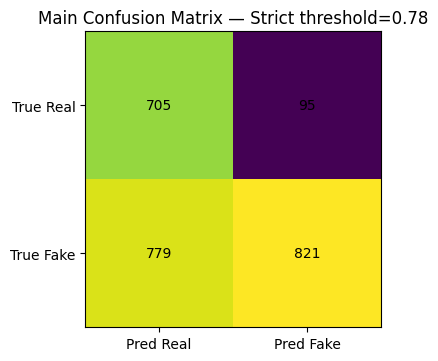

Đã lưu: /content/sbi_forensics/reports/confusion_matrix_real_fake_strict.png


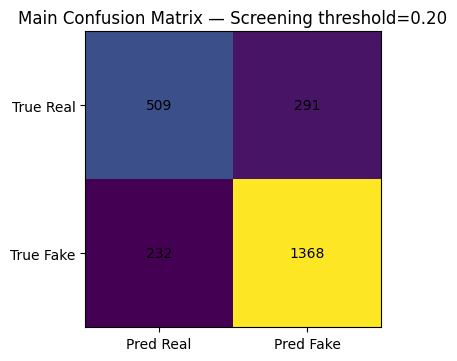

Đã lưu: /content/sbi_forensics/reports/confusion_matrix_real_fake_screening.png

Huấn luyện/đánh giá Cell 10 hoàn tất.
Model cuối cùng: /content/sbi_forensics/models/efficientnet_b2_sbi_final.pth
Model config: /content/sbi_forensics/models/model_config.json
Báo cáo: /content/sbi_forensics/reports


In [ ]:
# Cell 10 — Dự đoán real-vs-fake với TTA + strict/screening threshold + full metrics

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix
)

# Fallback nếu Cell 1 chưa khai báo
if "SCREENING_RECALL_TARGET" not in globals():
    SCREENING_RECALL_TARGET = 0.80

if "DEFAULT_THRESHOLD" not in globals():
    DEFAULT_THRESHOLD = 0.5


def compute_metrics(labels, probs, threshold: float = 0.5) -> dict:
    labels = list(labels)
    probs = list(probs)
    preds = [1 if p >= threshold else 0 for p in probs]

    cm = confusion_matrix(labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fpr = fp / (tn + fp) if (tn + fp) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        "threshold": float(threshold),
        "acc": float(accuracy_score(labels, preds)),
        "precision": float(precision),
        "recall": float(recall),
        "specificity": float(specificity),
        "f1": float(f1_score(labels, preds, zero_division=0)),
        "auc": float(roc_auc_score(labels, probs)) if len(set(labels)) == 2 else float("nan"),
        "fpr": float(fpr),
        "fnr": float(fnr),
        "confusion_matrix": cm.tolist()
    }


def threshold_sweep(labels, probs, thresholds=None) -> pd.DataFrame:
    if thresholds is None:
        thresholds = np.round(np.arange(0.20, 0.81, 0.01), 2)
    rows = []
    for th in thresholds:
        m = compute_metrics(labels, probs, threshold=float(th))
        rows.append({
            "threshold": float(th), "acc": m["acc"], "precision": m["precision"],
            "recall": m["recall"], "specificity": m["specificity"], "f1": m["f1"],
            "auc": m["auc"], "fpr": m["fpr"], "fnr": m["fnr"]
        })
    return pd.DataFrame(rows)


def select_screening_threshold(sweep_df: pd.DataFrame, recall_target: float = 0.80) -> float:
    candidates = sweep_df[sweep_df["recall"] >= recall_target]
    if len(candidates) > 0:
        best_row = candidates.sort_values(["f1", "specificity"], ascending=[False, False]).iloc[0]
    else:
        best_row = sweep_df.sort_values(["f1", "recall"], ascending=[False, False]).iloc[0]
    return float(best_row["threshold"])


def predict_csv(model, csv_path, use_tta: bool = True) -> pd.DataFrame:
    ds = FaceForgeryDataset(csv_path, transform=eval_tfms, return_meta=True)
    loader = make_loader(ds, BATCH_SIZE, shuffle=False)
    model.eval()
    rows = []

    with torch.no_grad():
        for imgs, labels, types, paths in tqdm(loader, desc="Dự đoán real-vs-fake"):
            imgs = imgs.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
                logits = model(imgs).squeeze(1)
                if use_tta:
                    imgs_flip = torch.flip(imgs, dims=[3])
                    logits_flip = model(imgs_flip).squeeze(1)

                    scaled_size = int(288 * 1.05)
                    imgs_scaled = TF.resize(imgs, [scaled_size, scaled_size])
                    imgs_crop = TF.center_crop(imgs_scaled, [288, 288]) # Chỉnh 288 theo kích thước input đã thay đổi ở trên, hoặc 256 nếu bạn vẫn dùng 256
                    logits_crop = model(imgs_crop).squeeze(1)

                    logits = (logits + logits_flip + logits_crop) / 3.0

                probs = torch.sigmoid(logits).cpu().numpy().tolist()

            labels_np = labels.cpu().numpy().tolist()
            for path, typ, label, prob in zip(paths, types, labels_np, probs):
                rows.append({"path": path, "type": typ, "label": int(label), "fake_score": float(prob)})

    return pd.DataFrame(rows)


def build_per_manipulation_metrics(pred_df: pd.DataFrame, threshold: float, model_tag: str, mode: str) -> pd.DataFrame:
    rows = []
    for fake_type in FAKE_FOLDER_NAMES:
        subset = pred_df[pred_df["type"].isin(["real", fake_type])]
        if subset["label"].nunique() == 2:
            m = compute_metrics(subset["label"].tolist(), subset["fake_score"].tolist(), threshold=threshold)
            rows.append({
                "model": model_tag, "mode": mode, "fake_type": fake_type,
                "n_real": int((subset["type"] == "real").sum()), "n_fake": int((subset["type"] == fake_type).sum()),
                "threshold": float(threshold), "acc": float(m["acc"]), "precision": float(m["precision"]),
                "recall": float(m["recall"]), "specificity": float(m["specificity"]), "f1": float(m["f1"]),
                "auc": float(m["auc"]), "fpr": float(m["fpr"]), "fnr": float(m["fnr"])
            })
    return pd.DataFrame(rows)


def evaluate_model_on_test(model, csv_path, strict_threshold: float, model_tag: str, use_tta: bool = True, recall_target: float = 0.80):
    pred_df = predict_csv(model, csv_path, use_tta=use_tta)
    labels = pred_df["label"].tolist()
    probs = pred_df["fake_score"].tolist()

    strict_metrics = compute_metrics(labels, probs, threshold=strict_threshold)
    sweep_df = threshold_sweep(labels, probs)
    screening_threshold = select_screening_threshold(sweep_df, recall_target=recall_target)
    screening_metrics = compute_metrics(labels, probs, threshold=screening_threshold)

    print(f"\n[{model_tag}] Strict threshold = {strict_threshold:.2f}")
    print(json.dumps(strict_metrics, indent=2))

    print(f"\n[{model_tag}] Screening threshold = {screening_threshold:.2f} | recall_target={recall_target:.2f}")
    print(json.dumps(screening_metrics, indent=2))

    print(f"\n[{model_tag}] Threshold sweep sample:")
    sample_thresholds = [0.30, 0.35, 0.40, 0.45, 0.48, 0.50, 0.55, 0.57, 0.60]
    print(sweep_df[sweep_df["threshold"].isin(sample_thresholds)])

    per_type_strict = build_per_manipulation_metrics(pred_df, strict_threshold, model_tag=model_tag, mode="strict")
    per_type_screening = build_per_manipulation_metrics(pred_df, screening_threshold, model_tag=model_tag, mode="screening")

    print(f"\n[{model_tag}] Per-manipulation — strict:")
    print(per_type_strict)
    print(f"\n[{model_tag}] Per-manipulation — screening:")
    print(per_type_screening)

    return {
        "pred_df": pred_df, "strict_threshold": float(strict_threshold), "screening_threshold": float(screening_threshold),
        "strict_metrics": strict_metrics, "screening_metrics": screening_metrics, "threshold_sweep": sweep_df,
        "per_type_strict": per_type_strict, "per_type_screening": per_type_screening
    }


# ============================================================
# Đánh giá model chính
# ============================================================

main_model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=1).to(DEVICE)
main_model, ckpt_main = load_best_checkpoint(main_model, best_path_main)

main_results = evaluate_model_on_test(
    main_model, real_fake_csv, strict_threshold=optimal_threshold,
    model_tag="main", use_tta=True, recall_target=SCREENING_RECALL_TARGET
)

pred_df_main = main_results["pred_df"]
overall_main = main_results["strict_metrics"]
overall_main_screening = main_results["screening_metrics"]
per_type_main = main_results["per_type_strict"]
per_type_main_screening = main_results["per_type_screening"]
main_screening_threshold = main_results["screening_threshold"]


# ============================================================
# Tổng hợp kết quả (Strict vs Screening)
# ============================================================

print("\n" + "=" * 60)
print("TỔNG HỢP KẾT QUẢ: Strict vs Screening Modes")
print("=" * 60)

summary_df = pd.DataFrame([
    {
        "model": "main", "mode": "strict", "threshold": optimal_threshold,
        "acc": overall_main["acc"], "precision": overall_main["precision"],
        "recall": overall_main["recall"], "specificity": overall_main["specificity"],
        "f1": overall_main["f1"], "auc": overall_main["auc"],
        "fpr": overall_main["fpr"], "fnr": overall_main["fnr"]
    },
    {
        "model": "main", "mode": "screening", "threshold": main_screening_threshold,
        "acc": overall_main_screening["acc"], "precision": overall_main_screening["precision"],
        "recall": overall_main_screening["recall"], "specificity": overall_main_screening["specificity"],
        "f1": overall_main_screening["f1"], "auc": overall_main_screening["auc"],
        "fpr": overall_main_screening["fpr"], "fnr": overall_main_screening["fnr"]
    }
])

print(summary_df)


# ============================================================
# Lưu artifact
# ============================================================

pred_csv = REPORT_DIR / "predictions_real_fake.csv"
pred_df_main.to_csv(pred_csv, index=False)

per_type_csv = REPORT_DIR / "per_manipulation_auc.csv"
per_type_main.to_csv(per_type_csv, index=False)

per_type_screening_csv = REPORT_DIR / "per_manipulation_screening_metrics.csv"
per_type_main_screening.to_csv(per_type_screening_csv, index=False)

summary_csv = REPORT_DIR / "model_summary_strict_screening.csv"
summary_df.to_csv(summary_csv, index=False)

threshold_sweep_csv = REPORT_DIR / "threshold_sweep_real_fake_main.csv"
main_results["threshold_sweep"].to_csv(threshold_sweep_csv, index=False)

test_metrics_real_fake_path = REPORT_DIR / "test_metrics_real_fake.json"
with open(test_metrics_real_fake_path, "w") as f:
    json.dump({
        "main": {
            "strict": overall_main,
            "screening": overall_main_screening,
            "strict_threshold": float(optimal_threshold),
            "screening_threshold": float(main_screening_threshold)
        }
    }, f, indent=2)


# ============================================================
# Confusion matrix — main strict và screening
# ============================================================

def save_confusion_matrix(cm, title, out_path):
    cm = np.array(cm)
    plt.figure(figsize=(4, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xticks([0, 1], ["Pred Real", "Pred Fake"])
    plt.yticks([0, 1], ["True Real", "True Fake"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("Đã lưu:", out_path)

cm_strict_path = REPORT_DIR / "confusion_matrix_real_fake_strict.png"
save_confusion_matrix(
    overall_main["confusion_matrix"],
    f"Main Confusion Matrix — Strict threshold={optimal_threshold:.2f}",
    cm_strict_path
)

cm_screening_path = REPORT_DIR / "confusion_matrix_real_fake_screening.png"
save_confusion_matrix(
    overall_main_screening["confusion_matrix"],
    f"Main Confusion Matrix — Screening threshold={main_screening_threshold:.2f}",
    cm_screening_path
)


# ============================================================
# Lưu model cuối + config sơ bộ
# ============================================================

final_path = MODEL_DIR / f"{MODEL_NAME}_sbi_final.pth"
shutil.copy(best_path_main, final_path)

model_config = {
    "model_name": MODEL_NAME,
    "image_size": 288, # Hoặc 256 tùy thuộc vào thiết lập Transform của bạn ở Cell 6
    "input_type": "face_crop",
    "label_0": "real",
    "label_1": "fake_or_sbi",
    "selected_model": "main",
    "thresholds": {
        "strict_threshold": float(optimal_threshold),
        "screening_threshold": float(main_screening_threshold),
        "screening_recall_target": float(SCREENING_RECALL_TARGET)
    },
    "best_checkpoints": {
        "main": str(best_path_main),
        "final_checkpoint": str(final_path)
    },
    "test_metrics_real_fake": {
        "main_strict": overall_main,
        "main_screening": overall_main_screening
    },
    "artifacts": {
        "predictions_real_fake": str(pred_csv),
        "per_manipulation_strict": str(per_type_csv),
        "per_manipulation_screening": str(per_type_screening_csv),
        "model_summary": str(summary_csv),
        "threshold_sweep_main": str(threshold_sweep_csv),
        "test_metrics_real_fake": str(test_metrics_real_fake_path),
        "confusion_matrix_strict": str(cm_strict_path),
        "confusion_matrix_screening": str(cm_screening_path)
    }
}

config_path = MODEL_DIR / "model_config.json"
with open(config_path, "w") as f:
    json.dump(model_config, f, indent=2)

print("\nHuấn luyện/đánh giá Cell 10 hoàn tất.")
print("Model cuối cùng:", final_path)
print("Model config:", config_path)
print("Báo cáo:", REPORT_DIR)

In [ ]:
# Cell 11 — Phân tích cấp video + Celeb-DF v2 cross-dataset test

# Celeb-DF v2 optional config
ENABLE_CELEBDF = False
celebdf_path = None
MAX_CELEBDF_VIDEOS = 100
MAX_CELEBDF_FRAMES_PER_VIDEO = 4

def aggregate_video_level(pred_df: pd.DataFrame) -> pd.DataFrame:
    """Gộp kết quả từ cấp frame lên cấp video (trung bình fake_score)."""
    df = pred_df.copy()
    df["video_id"] = df["path"].apply(lambda p: get_video_id(Path(p)))

    video_df = df.groupby("video_id").agg(
        fake_score=("fake_score", "mean"),
        label=("label", "first"),
        type=("type", "first")
    ).reset_index()
    return video_df


# --- Video-level metrics cho model chính ---
video_pred_df = aggregate_video_level(pred_df_main)

video_pred_csv = REPORT_DIR / "predictions_video_level.csv"
video_pred_df.to_csv(video_pred_csv, index=False)
print(f"Số video: {len(video_pred_df)}")

video_labels = video_pred_df["label"].tolist()
video_probs = video_pred_df["fake_score"].tolist()

# Đã sửa lại tên biến threshold cho khớp với Cell 10
video_overall_strict = compute_metrics(
    video_labels,
    video_probs,
    threshold=optimal_threshold
)

video_overall_screening = compute_metrics(
    video_labels,
    video_probs,
    threshold=main_screening_threshold
)

print("\nKết quả cấp video tổng thể — strict threshold:")
print(json.dumps(
    {k: v for k, v in video_overall_strict.items() if k != "confusion_matrix"},
    indent=2
))

print("\nKết quả cấp video tổng thể — screening threshold:")
print(json.dumps(
    {k: v for k, v in video_overall_screening.items() if k != "confusion_matrix"},
    indent=2
))

video_per_type = []
for fake_type in FAKE_FOLDER_NAMES:
    subset = video_pred_df[video_pred_df["type"].isin(["real", fake_type])]
    if subset["label"].nunique() == 2:
        m = compute_metrics(
            subset["label"].tolist(),
            subset["fake_score"].tolist(),
            threshold=main_screening_threshold
        )

        video_per_type.append({
            "fake_type": fake_type,
            "n_real_videos": int((subset["type"] == "real").sum()),
            "n_fake_videos": int((subset["type"] == fake_type).sum()),
            "threshold": float(main_screening_threshold),
            "video_acc": float(m["acc"]),
            "video_precision": float(m["precision"]),
            "video_recall": float(m["recall"]),
            "video_specificity": float(m["specificity"]),
            "video_f1": float(m["f1"]),
            "video_auc": float(m["auc"]),
            "video_fpr": float(m["fpr"]),
            "video_fnr": float(m["fnr"])
        })

video_type_df = pd.DataFrame(video_per_type)
video_type_csv = REPORT_DIR / "video_per_manipulation_auc.csv"
video_type_df.to_csv(video_type_csv, index=False)

with open(REPORT_DIR / "video_level_metrics.json", "w") as f:
    json.dump({
        "strict": video_overall_strict,
        "screening": video_overall_screening
    }, f, indent=2)

print("\nVideo-level per-manipulation (Screening Threshold):")
print(video_type_df)

# --- Lưu model_config.json (bao gồm video-level metrics) ---
# Tải file config đã lưu ở Cell 10 để cập nhật thêm thay vì ghi đè từ đầu
config_path = MODEL_DIR / "model_config.json"
if config_path.exists():
    with open(config_path, "r") as f:
        model_config = json.load(f)
else:
    model_config = {"artifacts": {}}

# Bổ sung các đánh giá video vào config
model_config["video_level_metrics"] = {
    "strict": video_overall_strict,
    "screening": video_overall_screening
}
model_config["artifacts"]["video_level_metrics"] = str(REPORT_DIR / "video_level_metrics.json")
model_config["artifacts"]["predictions_video_level"] = str(video_pred_csv)
model_config["artifacts"]["video_per_manipulation_auc"] = str(video_type_csv)

with open(config_path, "w") as f:
    json.dump(model_config, f, indent=2)

print("\nĐã cập nhật model config (thêm video-level metrics):", config_path)

# --- Celeb-DF v2 cross-dataset test (tùy chọn) ---
if ENABLE_CELEBDF and celebdf_path is not None:
    print("\n" + "=" * 60)
    print("CELEB-DF V2 CROSS-DATASET TEST")
    print("=" * 60)

    celebdf_test_dir = DATA_DIR / "celebdf_test_faces"
    celebdf_test_dir.mkdir(parents=True, exist_ok=True)

    celebdf_csv = META_DIR / f"celebdf_test_{DATA_VERSION}.csv"

    if celebdf_csv.exists():
        celebdf_df = pd.read_csv(celebdf_csv)
        print("Sử dụng cache Celeb-DF:", celebdf_csv)
    else:
        celebdf_records = []

        # Tìm thư mục real và fake trong Celeb-DF v2
        celebdf_real_dir = find_folder(celebdf_path, "Celeb-real")
        celebdf_synth_dir = find_folder(celebdf_path, "Celeb-synthesis")

        if celebdf_real_dir is None:
            celebdf_real_dir = find_folder(celebdf_path, "celeb-real")
        if celebdf_synth_dir is None:
            celebdf_synth_dir = find_folder(celebdf_path, "celeb-synthesis")

        if celebdf_real_dir and celebdf_synth_dir:
            # Extract real faces
            cdf_real_face_dir = celebdf_test_dir / "real"
            cdf_real_face_dir.mkdir(parents=True, exist_ok=True)

            cdf_real_vids = list_videos(celebdf_real_dir)[:MAX_CELEBDF_VIDEOS]
            for vp in tqdm(cdf_real_vids, desc="Celeb-DF real faces"):
                faces = extract_faces_from_video(
                    vp, cdf_real_face_dir,
                    max_frames_per_video=MAX_CELEBDF_FRAMES_PER_VIDEO,
                    frame_stride=25, prefix="cdf_real_"
                )
                for p in faces:
                    celebdf_records.append({"path": str(p), "label": 0, "type": "celebdf_real"})

            # Extract fake faces
            cdf_fake_face_dir = celebdf_test_dir / "fake"
            cdf_fake_face_dir.mkdir(parents=True, exist_ok=True)

            cdf_fake_vids = list_videos(celebdf_synth_dir)[:MAX_CELEBDF_VIDEOS]
            for vp in tqdm(cdf_fake_vids, desc="Celeb-DF fake faces"):
                faces = extract_faces_from_video(
                    vp, cdf_fake_face_dir,
                    max_frames_per_video=MAX_CELEBDF_FRAMES_PER_VIDEO,
                    frame_stride=25, prefix="cdf_fake_"
                )
                for p in faces:
                    celebdf_records.append({"path": str(p), "label": 1, "type": "celebdf_fake"})

            celebdf_df = pd.DataFrame(celebdf_records)

            if len(celebdf_df) > 0 and celebdf_df["label"].nunique() == 2:
                celebdf_df.to_csv(celebdf_csv, index=False)
                print("Đã lưu Celeb-DF test CSV:", celebdf_csv)
            else:
                print("Không đủ mẫu Celeb-DF. Bỏ qua.")
                ENABLE_CELEBDF = False
        else:
            print(f"Không tìm thấy Celeb-real/Celeb-synthesis trong {celebdf_path}.")
            print("Cấu trúc thư mục:", [str(p.name) for p in celebdf_path.iterdir()])
            ENABLE_CELEBDF = False

    # Đánh giá trên Celeb-DF
    if ENABLE_CELEBDF and celebdf_csv.exists():
        model, _ = load_best_checkpoint(model, best_path_main)

        celebdf_pred_df = predict_csv(model, celebdf_csv, use_tta=True)
        celebdf_metrics = compute_metrics(
            celebdf_pred_df["label"].tolist(),
            celebdf_pred_df["fake_score"].tolist(),
            threshold=optimal_threshold
        )

        print("\nCeleb-DF v2 metrics (main model):")
        print(json.dumps(celebdf_metrics, indent=2))

        celebdf_metrics_path = REPORT_DIR / "test_metrics_celebdf.json"
        with open(celebdf_metrics_path, "w") as f:
            json.dump({**celebdf_metrics, "threshold": optimal_threshold}, f, indent=2)

        celebdf_pred_csv = REPORT_DIR / "predictions_celebdf.csv"
        celebdf_pred_df.to_csv(celebdf_pred_csv, index=False)

        # Cập nhật model_config lần nữa nếu có Celeb-DF
        model_config["celebdf_metrics"] = {
            "acc": celebdf_metrics["acc"],
            "f1": celebdf_metrics["f1"],
            "auc": celebdf_metrics["auc"],
            "threshold": optimal_threshold
        }
        model_config["artifacts"]["celebdf_metrics"] = str(celebdf_metrics_path)
        model_config["artifacts"]["celebdf_predictions"] = str(celebdf_pred_csv)

        with open(config_path, "w") as f:
            json.dump(model_config, f, indent=2)

        print("Đã cập nhật model config với Celeb-DF metrics.")

else:
    print("\nBỏ qua Celeb-DF v2 test (dataset không khả dụng).")

print("\nĐã lưu:", video_pred_csv)
print("Đã lưu:", video_type_csv)

Số video: 600

Kết quả cấp video tổng thể — strict threshold:
{
  "threshold": 0.7799999999999997,
  "acc": 0.5883333333333334,
  "precision": 0.9090909090909091,
  "recall": 0.425,
  "specificity": 0.915,
  "f1": 0.5792163543441227,
  "auc": 0.8485625,
  "fpr": 0.085,
  "fnr": 0.575
}

Kết quả cấp video tổng thể — screening threshold:
{
  "threshold": 0.2,
  "acc": 0.82,
  "precision": 0.8201754385964912,
  "recall": 0.935,
  "specificity": 0.59,
  "f1": 0.8738317757009346,
  "auc": 0.8485625,
  "fpr": 0.41,
  "fnr": 0.065
}

Video-level per-manipulation (Screening Threshold):
        fake_type  n_real_videos  n_fake_videos  threshold  video_acc  \
0       Deepfakes            200            100        0.2   0.713333   
1       Face2Face            200            100        0.2   0.713333   
2        FaceSwap            200            100        0.2   0.706667   
3  NeuralTextures            200            100        0.2   0.686667   

   video_precision  video_recall  video_specifici

Checkpoint được dùng cho Grad-CAM: /content/sbi_forensics/models/efficientnet_b2_mixed_sbi_v4_with_real_fake_train_main_best.pth
Grad-CAM — Mẫu FAKE:


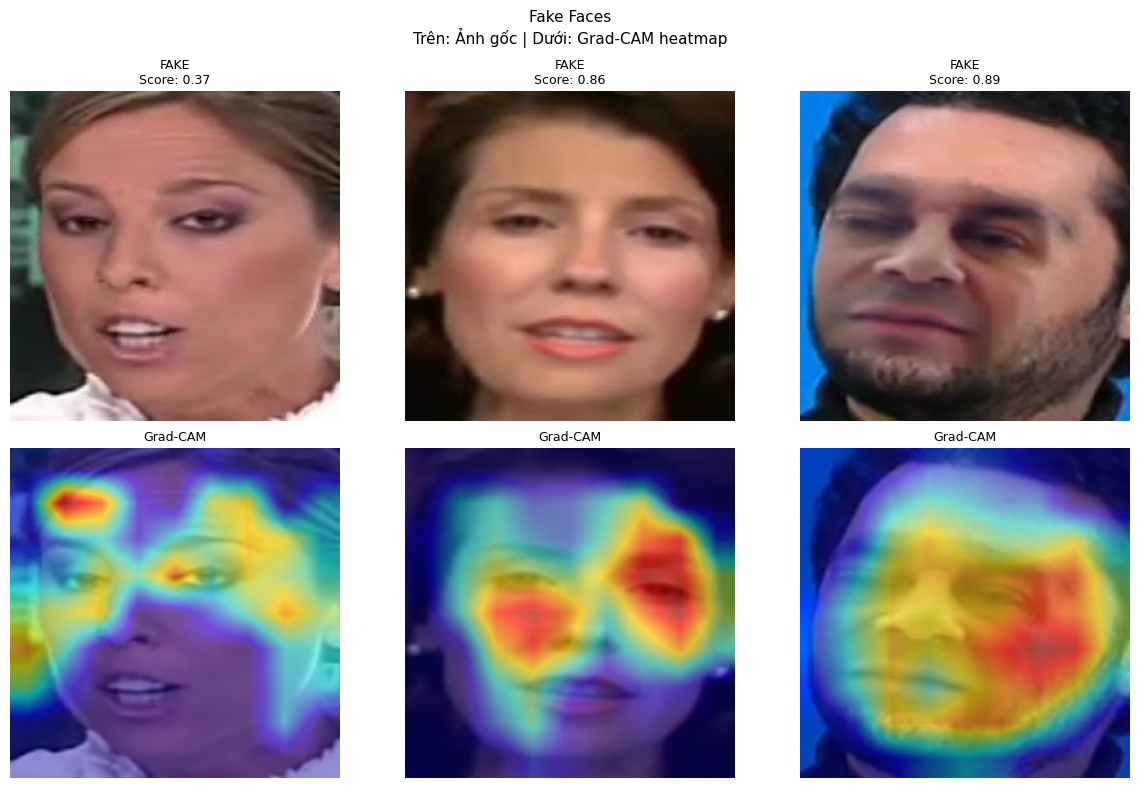

Đã lưu: /content/sbi_forensics/reports/gradcam_mixed_sbi_v4_with_real_fake_train_fake_faces.png

Grad-CAM — Mẫu REAL:


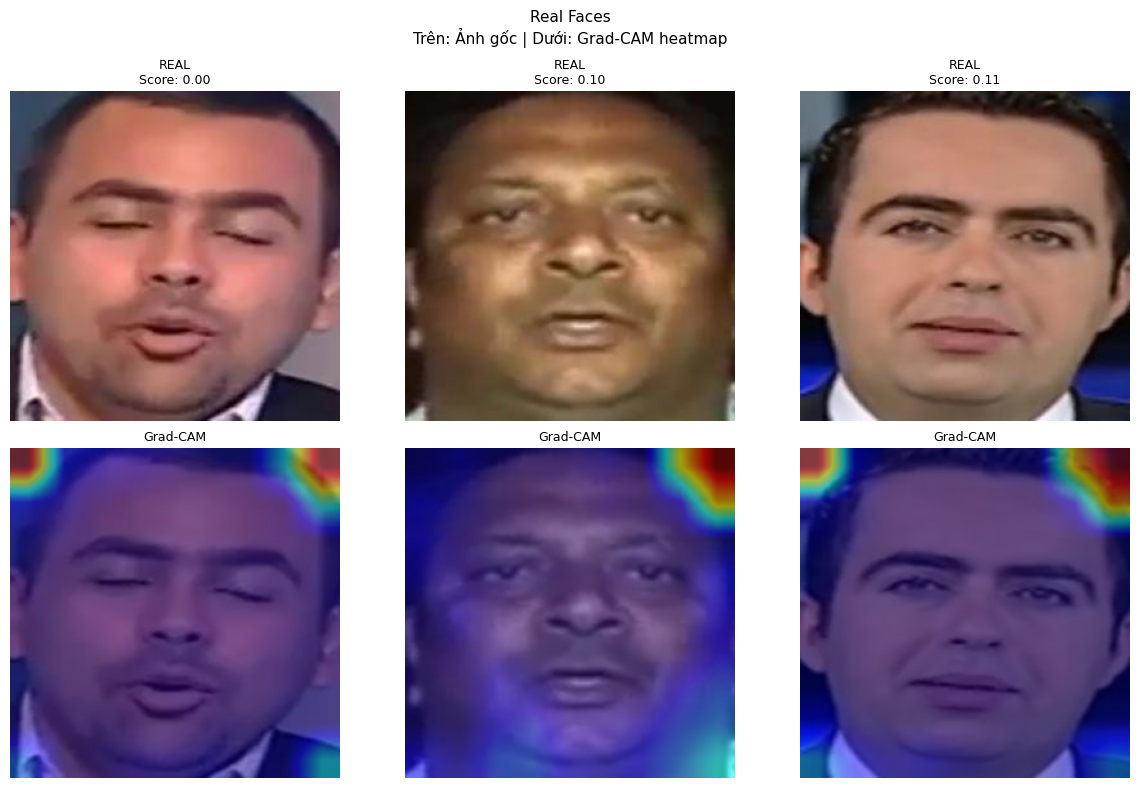

Đã lưu: /content/sbi_forensics/reports/gradcam_mixed_sbi_v4_with_real_fake_train_real_faces.png

Tất cả artifact đã được lưu tại: /content/sbi_forensics/reports
File model để tích hợp vào app: /content/sbi_forensics/models/efficientnet_b2_sbi_final.pth


In [ ]:
# Cell 12 — Trực quan hóa Grad-CAM

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


def get_gradcam_heatmap(
    model,
    img_tensor: torch.Tensor
) -> Tuple[np.ndarray, np.ndarray]:
    """Tạo heatmap Grad-CAM cho một ảnh.

    Sử dụng lớp conv_head của EfficientNet làm target layer
    để hiển thị vùng model chú ý khi đưa ra dự đoán.

    Args:
        model: Mô hình EfficientNet-B2.
        img_tensor: Tensor ảnh đã normalize, shape (C, H, W).

    Returns:
        Tuple (grayscale_cam, visualization):
            - grayscale_cam: Heatmap grayscale (H, W), giá trị [0, 1].
            - visualization: Ảnh RGB overlay heatmap lên ảnh gốc.
    """
    target_layers = [model.conv_head]

    cam = GradCAM(
        model=model,
        target_layers=target_layers
    )

    input_tensor = img_tensor.unsqueeze(0)

    grayscale_cam = cam(input_tensor=input_tensor, targets=None)
    grayscale_cam = grayscale_cam[0]

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img_np = img_tensor.permute(1, 2, 0).detach().cpu().numpy()
    img_np = np.clip(img_np * std + mean, 0, 1).astype(np.float32)

    visualization = show_cam_on_image(
        img_np,
        grayscale_cam,
        use_rgb=True
    )

    return grayscale_cam, visualization


def visualize_gradcam_batch(
    model,
    csv_path,
    n_samples: int = 3,
    label_filter: Optional[int] = None,
    title: str = ""
) -> Optional[Path]:
    """Trực quan hóa Grad-CAM cho một batch mẫu từ CSV.

    Hiển thị ảnh gốc và heatmap Grad-CAM cạnh nhau,
    giúp phân tích vùng model chú ý để phân loại real/fake.

    Args:
        model: Mô hình đã huấn luyện.
        csv_path: Đường dẫn CSV chứa dữ liệu test.
        n_samples: Số mẫu hiển thị.
        label_filter: Lọc theo label (0=real, 1=fake, None=tất cả).
        title: Tiêu đề biểu đồ.

    Returns:
        Đường dẫn file ảnh Grad-CAM đã lưu, hoặc None nếu không có mẫu.
    """
    model.eval()

    csv_path = Path(csv_path)
    assert csv_path.exists(), f"Không tìm thấy CSV: {csv_path}"

    df = pd.read_csv(csv_path)

    if label_filter is not None:
        df = df[df["label"] == label_filter]

    if len(df) == 0:
        print("Không tìm thấy mẫu nào cho label_filter:", label_filter)
        return None

    df = df.sample(min(n_samples, len(df)), random_state=SEED)

    n = len(df)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

    if n == 1:
        axes = axes[:, np.newaxis]

    for col, (_, row) in enumerate(df.iterrows()):
        img_pil = Image.open(row["path"]).convert("RGB")
        img_tensor = eval_tfms(img_pil).to(DEVICE)

        with torch.no_grad():
            with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
                fake_score = torch.sigmoid(
                    model(img_tensor.unsqueeze(0)).squeeze()
                ).item()

        _, vis = get_gradcam_heatmap(model, img_tensor)

        label_str = "FAKE" if row["label"] == 1 else "REAL"

        axes[0, col].imshow(img_pil)
        axes[0, col].set_title(f"{label_str}\nScore: {fake_score:.2f}", fontsize=9)
        axes[0, col].axis("off")

        axes[1, col].imshow(vis)
        axes[1, col].set_title("Grad-CAM", fontsize=9)
        axes[1, col].axis("off")

    plt.suptitle(f"{title}\nTrên: Ảnh gốc | Dưới: Grad-CAM heatmap", fontsize=11)
    plt.tight_layout()

    out_path = REPORT_DIR / f"gradcam_{DATA_VERSION}_{title.lower().replace(' ', '_')}.png"

    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Đã lưu:", out_path)

    return out_path


# --- Tải checkpoint và chạy Grad-CAM ---

# --- Tải checkpoint tốt nhất và chạy Grad-CAM ---

MODEL_DIR = Path("/content/sbi_forensics/models")
REPORT_DIR = Path("/content/sbi_forensics/reports")

# Tìm checkpoint best phù hợp
checkpoint_candidates = sorted(
    MODEL_DIR.glob("*_main_best.pth"),
    key=lambda p: p.stat().st_mtime,
    reverse=True
)

if len(checkpoint_candidates) == 0:
    checkpoint_candidates = sorted(
        MODEL_DIR.glob("*best*.pth"),
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )

assert len(checkpoint_candidates) > 0, "Không tìm thấy checkpoint best trong MODEL_DIR."

best_path = checkpoint_candidates[0]
print("Checkpoint được dùng cho Grad-CAM:", best_path)

# Nếu final_path chưa tồn tại thì tạo lại từ best_path
final_path = MODEL_DIR / f"{MODEL_NAME}_sbi_final.pth"

if not final_path.exists():
    shutil.copy(best_path, final_path)

model, checkpoint = load_best_checkpoint(model, best_path)

print("Grad-CAM — Mẫu FAKE:")
visualize_gradcam_batch(
    model,
    real_fake_csv,
    n_samples=3,
    label_filter=1,
    title="Fake Faces"
)

print("\nGrad-CAM — Mẫu REAL:")
visualize_gradcam_batch(
    model,
    real_fake_csv,
    n_samples=3,
    label_filter=0,
    title="Real Faces"
)

print("\nTất cả artifact đã được lưu tại:", REPORT_DIR)
print("File model để tích hợp vào app:", final_path)
